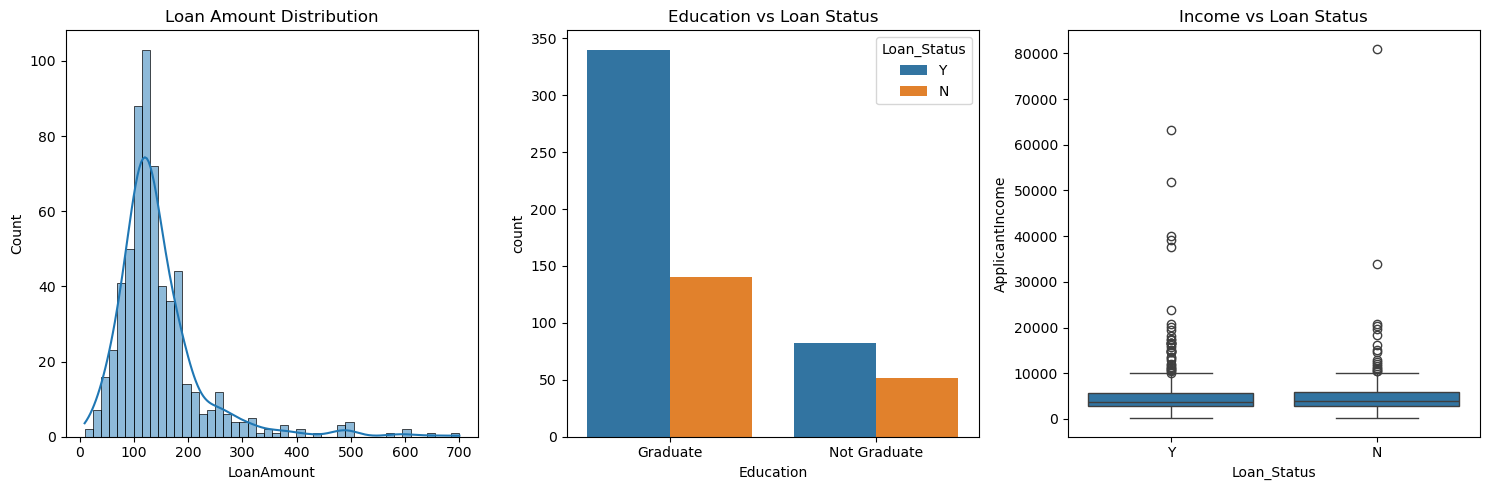

Accuracy Score: 78.86%


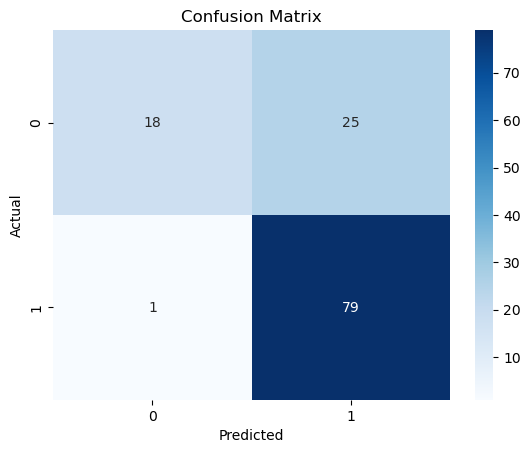

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. LOAD DATASET
url = "https://github.com/ShehrozGhouri/Developers-Hub-DataScience-Internship/raw/refs/heads/main/Task%202%20--%20Credit%20Risk%20Prediction%20Project/Credit%20Risk%20Prediction.csv"
df = pd.read_csv(url)

# 2. HANDLE MISSING DATA
# Filling Categorical with Mode and Numerical with Median
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

# 3. VISUALIZE KEY FEATURES
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['LoanAmount'], kde=True)
plt.title('Loan Amount Distribution')

plt.subplot(1, 3, 2)
sns.countplot(data=df, x='Education', hue='Loan_Status')
plt.title('Education vs Loan Status')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='Loan_Status', y='ApplicantIncome')
plt.title('Income vs Loan Status')

plt.tight_layout()
plt.show()

# 4. PREPROCESSING
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Property_Area'] = df['Property_Area'].map({'Urban': 2, 'Semiurban': 1, 'Rural': 0})
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# 5. TRAIN LOGISTIC REGRESSION
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# 6. RESULTS & CONFUSION MATRIX
y_pred = model.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)*100:.2f}%")

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [3]:
import joblib

# Save the trained model to a file named 'credit_risk_model.pkl'
joblib.dump(model, 'Credit_Risk_Model.pkl')

print("Model saved successfully as credit_risk_model.pkl!")

Model saved successfully as credit_risk_model.pkl!
